# Pix2Pix

In [1]:
# =========================
# Pix2Pix (128x128 tiles)
# Paste into a new notebook
# =========================

# ---------- Cell 1: Imports & Config ----------
import os
import glob
import random
from pathlib import Path

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

from torchvision import transforms
from torchvision.utils import make_grid, save_image

import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", DEVICE)

# Choose 128 (recommended)
TILE_SIZE = 128
BATCH_SIZE = 16  # reduce if needed
NUM_WORKERS = 0 # increase on Linux if you want
LR = 2e-4
BETA1, BETA2 = 0.5, 0.999

EPOCHS = 15             # run longer, choose best epoch visually
LAMBDA_L1 = 75.0         # <-- change from 50 to 75
WARMUP_EPOCHS = 3

# Paths (EDIT THESE)
DAMAGED_DIR = r"/Users/martashkreli/Desktop/tiledsets/train_indexed_images/damaged"
UNDAMAGED_DIR = r"/Users/martashkreli/Desktop/tiledsets/train_indexed_images/undamaged"

OUT_DIR = "./pix2pix_outputs"
CKPT_DIR = "./pix2pix_checkpoints"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

Using device: cuda


'\n# Paths (EDIT THESE)\nDAMAGED_DIR = r"/Users/martashkreli/Desktop/tiledsets/train_indexed_images/damaged"\nUNDAMAGED_DIR = r"/Users/martashkreli/Desktop/tiledsets/train_indexed_images/undamaged"\n\nOUT_DIR = "./pix2pix_outputs"\nCKPT_DIR = "./pix2pix_checkpoints"\nos.makedirs(OUT_DIR, exist_ok=True)\nos.makedirs(CKPT_DIR, exist_ok=True)\n'

In [5]:
# ---------- Cell 2: Dataset (FIXED) ----------
import os, glob
from pathlib import Path
from PIL import Image

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

# --- Pairing: use RELATIVE PATH (keeps ID folder + filename) ---
def rel_key(path, root_dir):
    p = Path(path)
    root = Path(root_dir)
    return str(p.relative_to(root)).replace("\\", "/")

def build_pairs(damaged_dir, undamaged_dir,
                exts=(".png",".jpg",".jpeg",".webp",".PNG",".JPG",".JPEG",".WEBP")):
    d_files = []
    for e in exts:
        d_files += glob.glob(os.path.join(damaged_dir, "**", f"*{e}"), recursive=True)

    u_files = []
    for e in exts:
        u_files += glob.glob(os.path.join(undamaged_dir, "**", f"*{e}"), recursive=True)

    d_map = {rel_key(p, damaged_dir): p for p in d_files}
    u_map = {rel_key(p, undamaged_dir): p for p in u_files}

    keys = sorted(set(d_map.keys()) & set(u_map.keys()))
    return [(d_map[k], u_map[k]) for k in keys]

# --- Informativeness: Sobel edge energy ---
def is_informative(img, edge_thresh=0.03):
    gray = img.mean(dim=0, keepdim=True).unsqueeze(0)  # (1,1,H,W)

    sobel_x = torch.tensor([[1,0,-1],[2,0,-2],[1,0,-1]],
                            dtype=gray.dtype, device=gray.device).view(1,1,3,3)
    sobel_y = torch.tensor([[1,2,1],[0,0,0],[-1,-2,-1]],
                            dtype=gray.dtype, device=gray.device).view(1,1,3,3)

    gx = F.conv2d(gray, sobel_x, padding=1)
    gy = F.conv2d(gray, sobel_y, padding=1)

    edge_energy = torch.mean(torch.sqrt(gx**2 + gy**2))
    return edge_energy.item() > edge_thresh

class PairedTilesDataset(Dataset):
    def __init__(self, pairs, edge_thresh=0.03):
        # IMPORTANT: no resize, tiles are already 128x128
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3),  # [-1, 1]
        ])

        filtered = []
        removed = 0

        for d_path, u_path in pairs:
            d = self.transform(Image.open(d_path).convert("RGB"))
            u = self.transform(Image.open(u_path).convert("RGB"))

            if is_informative(d, edge_thresh) or is_informative(u, edge_thresh):
                filtered.append((d_path, u_path))
            else:
                removed += 1

        print(f"Filtered out {removed} low-information tiles (edge_thresh={edge_thresh})")
        print(f"Remaining tiles: {len(filtered)}")

        self.pairs = filtered

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        d_path, u_path = self.pairs[idx]
        d = self.transform(Image.open(d_path).convert("RGB"))
        u = self.transform(Image.open(u_path).convert("RGB"))
        return d, u, Path(d_path).name

# --- Build pairs ---
pairs = build_pairs(DAMAGED_DIR, UNDAMAGED_DIR)
print("Found paired tiles:", len(pairs))
assert len(pairs) > 0, "No pairs found. Check your folders / filenames."

# --- Build dataset ---
dataset = PairedTilesDataset(pairs, edge_thresh=0.03)

# --- Train/Val split ---
val_ratio = 0.1
val_len = int(len(dataset) * val_ratio)
train_len = len(dataset) - val_len

train_ds, val_ds = random_split(
    dataset,
    [train_len, val_len],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=False
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=False
)

print("Train:", len(train_ds), "Val:", len(val_ds))

Found paired tiles: 417
Filtered out 0 low-information tiles (edge_thresh=0.03)
Remaining tiles: 417
Train: 376 Val: 41


In [6]:
# ---------- Cell 3: Model blocks (REPLACE) ----------
def init_weights(m):
    if isinstance(m, nn.Conv2d):
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias.data, 0)

class DownBlock(nn.Module):
    def __init__(self, in_c, out_c, norm=True):
        super().__init__()
        layers = [nn.Conv2d(in_c, out_c, 4, 2, 1, bias=False)]
        if norm:
            layers += [nn.InstanceNorm2d(out_c, affine=True)]
        layers += [nn.LeakyReLU(0.2, inplace=True)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class UpBlock(nn.Module):
    def __init__(self, in_c, out_c, dropout=False):
        super().__init__()
        layers = [
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(in_c, out_c, kernel_size=3, stride=1, padding=1, bias=False),
            nn.InstanceNorm2d(out_c, affine=True),
            nn.ReLU(inplace=True),
        ]
        if dropout:
            layers += [nn.Dropout(0.5)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class UNetGenerator(nn.Module):
    def __init__(self, in_c=3, out_c=3, base=64):
        super().__init__()
        # Encoder
        self.d1 = DownBlock(in_c, base, norm=False)       # 128 -> 64
        self.d2 = DownBlock(base, base*2)                # 64 -> 32
        self.d3 = DownBlock(base*2, base*4)              # 32 -> 16
        self.d4 = DownBlock(base*4, base*8)              # 16 -> 8
        self.d5 = DownBlock(base*8, base*8)              # 8 -> 4
        self.d6 = DownBlock(base*8, base*8)              # 4 -> 2
        self.d7 = DownBlock(base*8, base*8, norm=False)  # 2 -> 1

        # Decoder
        self.u1 = UpBlock(base*8,  base*8, dropout=True)   # 1 -> 2
        self.u2 = UpBlock(base*16, base*8, dropout=True)   # 2 -> 4
        self.u3 = UpBlock(base*16, base*8, dropout=True)   # 4 -> 8
        self.u4 = UpBlock(base*16, base*4, dropout=False)  # 8 -> 16
        self.u5 = UpBlock(base*8,  base*2, dropout=False)  # 16 -> 32
        self.u6 = UpBlock(base*4,  base,   dropout=False)  # 32 -> 64

        # Final: upsample + conv (no ConvTranspose)
        self.final = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),           # 64 -> 128
            nn.Conv2d(base*2, out_c, kernel_size=3, padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        d1 = self.d1(x)
        d2 = self.d2(d1)
        d3 = self.d3(d2)
        d4 = self.d4(d3)
        d5 = self.d5(d4)
        d6 = self.d6(d5)
        d7 = self.d7(d6)

        u1 = self.u1(d7)
        u2 = self.u2(torch.cat([u1, d6], dim=1))
        u3 = self.u3(torch.cat([u2, d5], dim=1))
        u4 = self.u4(torch.cat([u3, d4], dim=1))
        u5 = self.u5(torch.cat([u4, d3], dim=1))
        u6 = self.u6(torch.cat([u5, d2], dim=1))

        out = self.final(torch.cat([u6, d1], dim=1))
        return out

class PatchDiscriminator(nn.Module):
    def __init__(self, in_c=3, base=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c*2, base, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base, base*2, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(base*2, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base*2, base*4, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(base*4, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base*4, base*8, 4, 1, 1, bias=False),
            nn.InstanceNorm2d(base*8, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base*8, 1, 4, 1, 1)
        )

    def forward(self, x_in, x_tgt):
        return self.net(torch.cat([x_in, x_tgt], dim=1))

In [7]:
# ---------- Cell 4: Init models & losses ----------
G = UNetGenerator().to(DEVICE)
D = PatchDiscriminator().to(DEVICE)
G.apply(init_weights)
D.apply(init_weights)

criterion_gan = nn.BCEWithLogitsLoss()
criterion_l1 = nn.L1Loss()

opt_G = optim.Adam(G.parameters(), lr=LR, betas=(BETA1, BETA2))
opt_D = optim.Adam(D.parameters(), lr=LR, betas=(BETA1, BETA2))

def denorm(x):
    return (x * 0.5 + 0.5).clamp(0, 1)

In [8]:
# ---------- Cell 5: Train helpers ----------
@torch.no_grad()
@torch.no_grad()
def save_samples(epoch, loader, max_n=8):
    G.eval()
    d, u, names = next(iter(loader))
    d, u = d.to(DEVICE), u.to(DEVICE)
    fake = G(d)

    rows = []
    for i in range(min(max_n, d.size(0))):
        rows += [denorm(d[i]), denorm(fake[i]), denorm(u[i])]
    grid = make_grid(rows, nrow=3)

    path = os.path.join(OUT_DIR, f"samples_epoch_{epoch:03d}.png")
    save_image(grid, path)

    from IPython.display import display
    from PIL import Image
    display(Image.open(path))

    G.train()

def save_ckpt(epoch):
    torch.save({
        "epoch": epoch,
        "G": G.state_dict(),
        "D": D.state_dict(),
        "opt_G": opt_G.state_dict(),
        "opt_D": opt_D.state_dict(),
    }, os.path.join(CKPT_DIR, f"pix2pix_epoch_{epoch:03d}.pt"))


Epoch 1/2 | G: 24.8426 (L1 only) | D: 0.7640


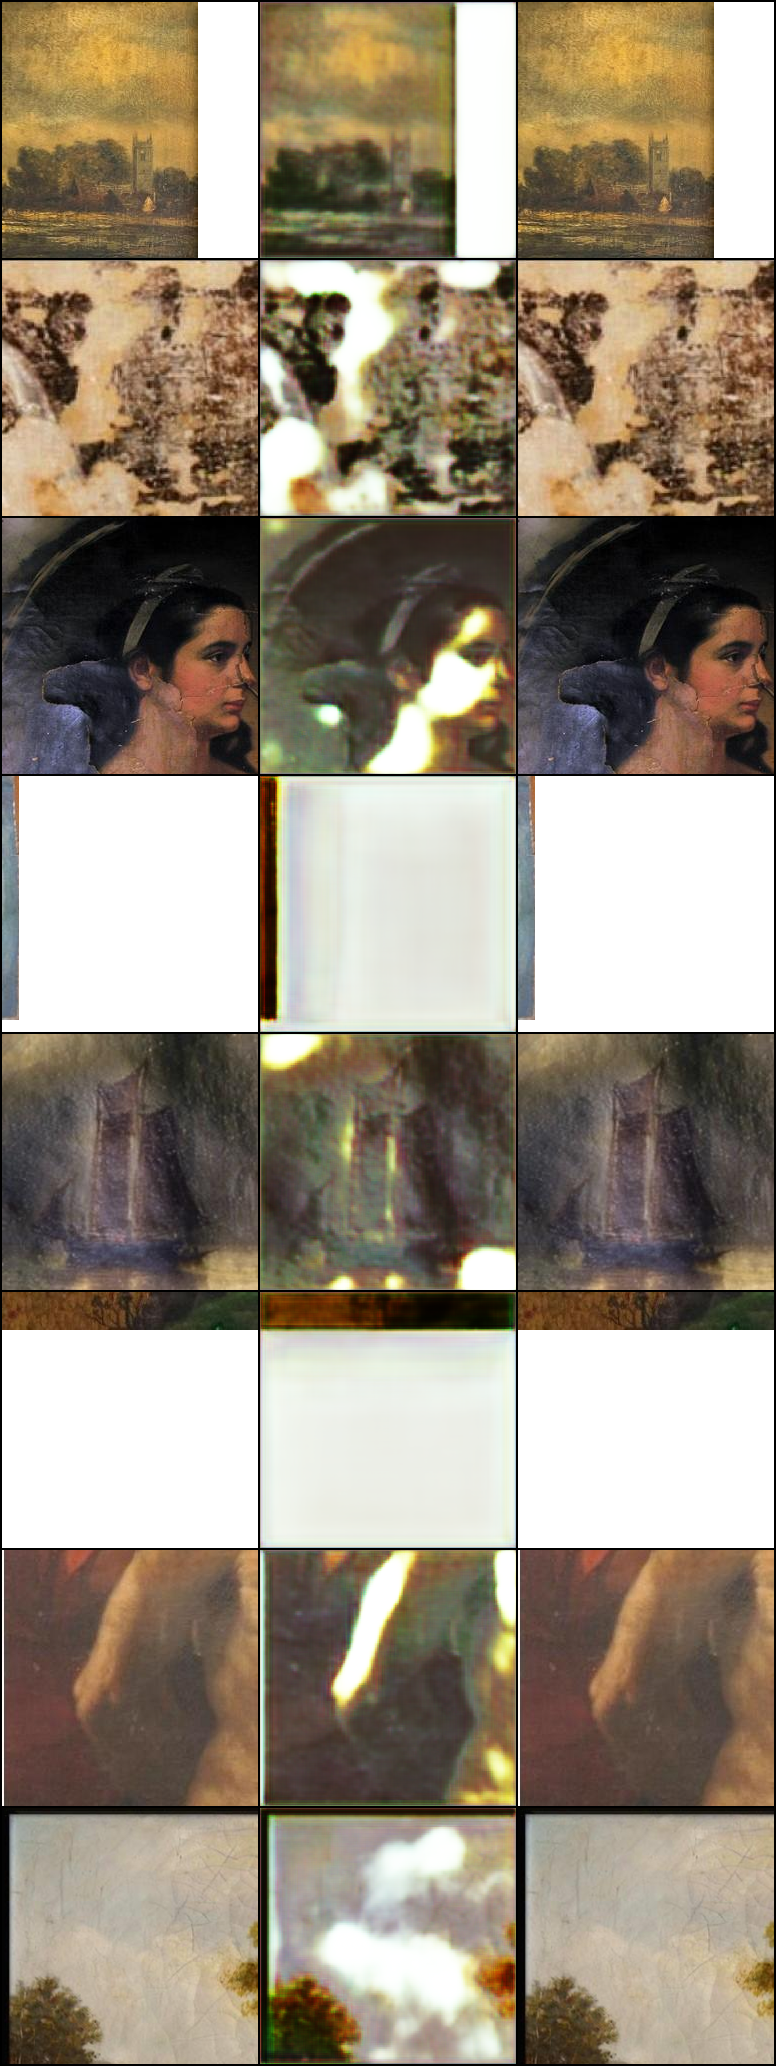

Epoch 2/2 | G: 11.7069 (L1 only) | D: 0.6726


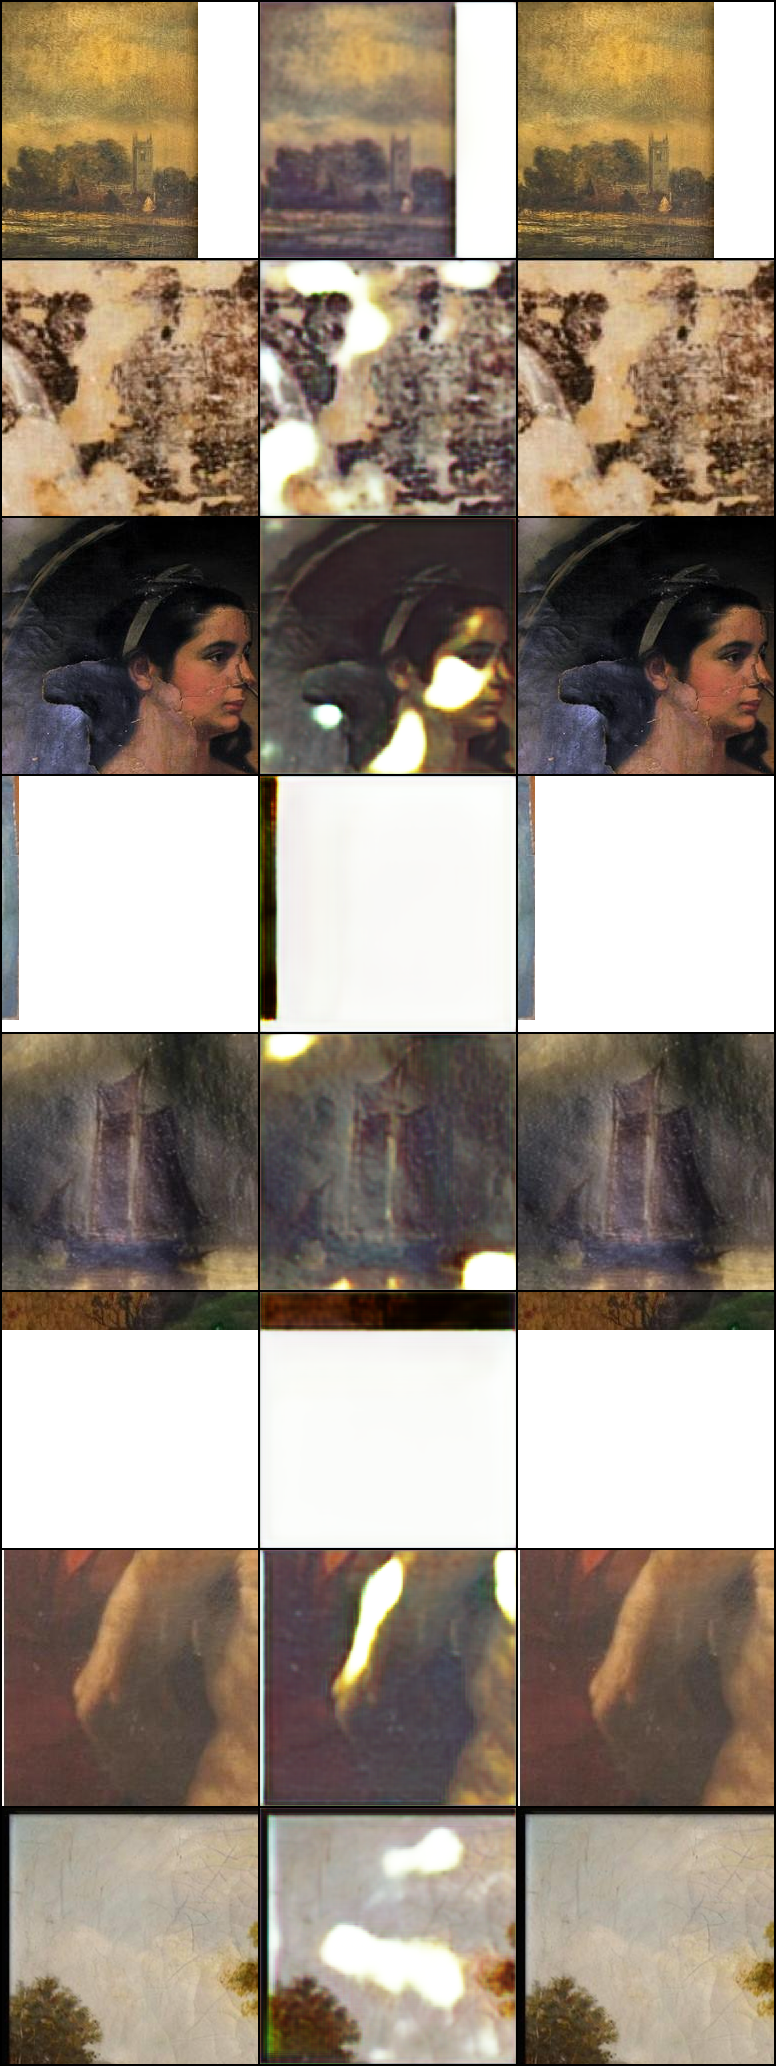

Done.


In [9]:
# ---------- Cell: Training loop (REPLACE THIS CELL) ----------
G.train()
D.train()

for epoch in range(1, EPOCHS + 1):
    g_loss_running = 0.0
    d_loss_running = 0.0

    for damaged, undamaged, _ in train_loader:
        damaged = damaged.to(DEVICE)
        undamaged = undamaged.to(DEVICE)

        # ======================
        # 1) Train Discriminator
        # ======================
        with torch.no_grad():
            fake = G(damaged)

        pred_real = D(damaged, undamaged)
        pred_fake = D(damaged, fake.detach())

        real_labels = torch.ones_like(pred_real)
        fake_labels = torch.zeros_like(pred_fake)

        loss_D_real = criterion_gan(pred_real, real_labels)
        loss_D_fake = criterion_gan(pred_fake, fake_labels)
        loss_D = 0.5 * (loss_D_real + loss_D_fake)

        opt_D.zero_grad(set_to_none=True)
        loss_D.backward()
        opt_D.step()

        # ======================
        # 2) Train Generator
        # ======================
        fake = G(damaged)
        pred_fake_for_G = D(damaged, fake)

        loss_G_l1 = criterion_l1(fake, undamaged) * LAMBDA_L1

        # Warmup: only L1 for first WARMUP_EPOCHS epochs
        if epoch <= WARMUP_EPOCHS:
            loss_G = loss_G_l1
            loss_G_gan = torch.tensor(0.0, device=DEVICE)
        else:
            loss_G_gan = criterion_gan(pred_fake_for_G, torch.ones_like(pred_fake_for_G))
            loss_G = loss_G_gan + loss_G_l1

        opt_G.zero_grad(set_to_none=True)
        loss_G.backward()
        opt_G.step()

        g_loss_running += loss_G.item()
        d_loss_running += loss_D.item()

    g_loss_running /= max(1, len(train_loader))
    d_loss_running /= max(1, len(train_loader))

    # Print both components so you can see when GAN kicks in
    if epoch <= WARMUP_EPOCHS:
        print(f"Epoch {epoch}/{EPOCHS} | G: {g_loss_running:.4f} (L1 only) | D: {d_loss_running:.4f}")
    else:
        print(f"Epoch {epoch}/{EPOCHS} | G: {g_loss_running:.4f} | D: {d_loss_running:.4f}")

    # Save every epoch so you can pick best visually
    save_samples(epoch, val_loader)
    if epoch % 5 == 0 or epoch == 1:
        save_ckpt(epoch)

print("Done.")

In [10]:
# -------------------------
# Test & Evaluation
# -------------------------

def benchmark_pix2pix_quantitative():
    """
    Evaluates the Pix2Pix Generator (G) on the validation dataset (val_loader).
    Uses existing variables 'G', 'val_loader', and 'DEVICE' defined in the notebook.
    """
    print("🕵️‍♂️ Checking Pix2Pix environment variables...")

    # Locate Generator (G)
    if 'G' in globals():
        gen_model = globals()['G']
        print("Model 'G' found.")
    else:
        print("ERROR: Variable 'G' is missing. Did you run the training cells?")
        return

    # Locate Loader (val_loader)
    if 'val_loader' in globals():
        loader = globals()['val_loader']
        print(f"Loader 'val_loader' found ({len(loader.dataset)} images).")
    else:
        print("ERROR: Variable 'val_loader' is missing.")
        return

    # Locate Device
    if 'DEVICE' in globals():
         device = globals()['DEVICE']
    else:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print(f"Starting evaluation on {device}...")

    gen_model.eval()
    psnr_scores = []
    ssim_scores = []

    with torch.no_grad():
        for batch in loader:
            # The Pix2Pix loader returns: (damaged, undamaged, filenames)
            # We only need index 0 (Input) and index 1 (Target)
            inputs = batch[0].to(device)
            targets = batch[1].to(device)

            # Inference (Generate Fake Images)
            fakes = gen_model(inputs)

            # Denormalize: Convert from [-1, 1] range back to [0, 1]
            fakes = (fakes * 0.5 + 0.5).clamp(0, 1).cpu().numpy()
            targets_np = (targets * 0.5 + 0.5).cpu().numpy()

            # Calculate metrics for each image in the batch
            batch_size = fakes.shape[0]
            for i in range(batch_size):
                # Permute dimensions: (C, H, W) -> (H, W, C) for scikit-image
                img_pred = np.moveaxis(fakes[i], 0, -1)
                img_true = np.moveaxis(targets_np[i], 0, -1)

                # Calculate PSNR & SSIM
                p = psnr(img_true, img_pred, data_range=1.0)
                s = ssim(img_true, img_pred, data_range=1.0, channel_axis=2)

                psnr_scores.append(p)
                ssim_scores.append(s)

    # Display Final Results
    print("\n" + "="*40)
    print(f" PIX2PIX QUANTITATIVE RESULTS")
    print("="*40)
    print(f"Average PSNR: {np.mean(psnr_scores):.2f} dB")
    print(f"Average SSIM: {np.mean(ssim_scores):.4f}")
    print("="*40)

# Run the benchmark
benchmark_pix2pix_quantitative()

🕵️‍♂️ Checking Pix2Pix environment variables...
Model 'G' found.
Loader 'val_loader' found (41 images).
Starting evaluation on cuda...

 PIX2PIX QUANTITATIVE RESULTS
Average PSNR: 22.05 dB
Average SSIM: 0.8095
